In [13]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from aux import plot_phase_space, plot_lattice
from data import parser
from structure import create_lebt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initial Bunch

In [14]:
B0 = parser()
B0T = rft.Bunch6dT(B0)

M0 = B0T.get_phase_space("%X %xp %Y %yp")

x  = M0[:,0]
xp = M0[:,1]
y  = M0[:,2]
yp = M0[:,3]


#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y, yp, "y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")



N: 15673, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 2.89e-06 A, Charge: 6 e


### LEBT

K1_dip: 0.0 1/m^2, Bfield_dip: 0.08879570293932051 T
B:0.08879570293932051 T

X-X'
emit = 0.1528479657244231 mm·mrad
beta = 0.71346664981588 mm/mrad
alpha = -0.04962415359025255

Y-Y'
emit = 0.1527673522864096 mm·mrad
beta = 0.7088730679130638 mm/mrad
alpha = -0.04981256816339867

4D
emit4D = 0.004676705630053463 (mm·mrad)^2
beta medio: 0.0057151717824466455
s final [m]: 0.33753804547129884
ct final [m]: 59.06


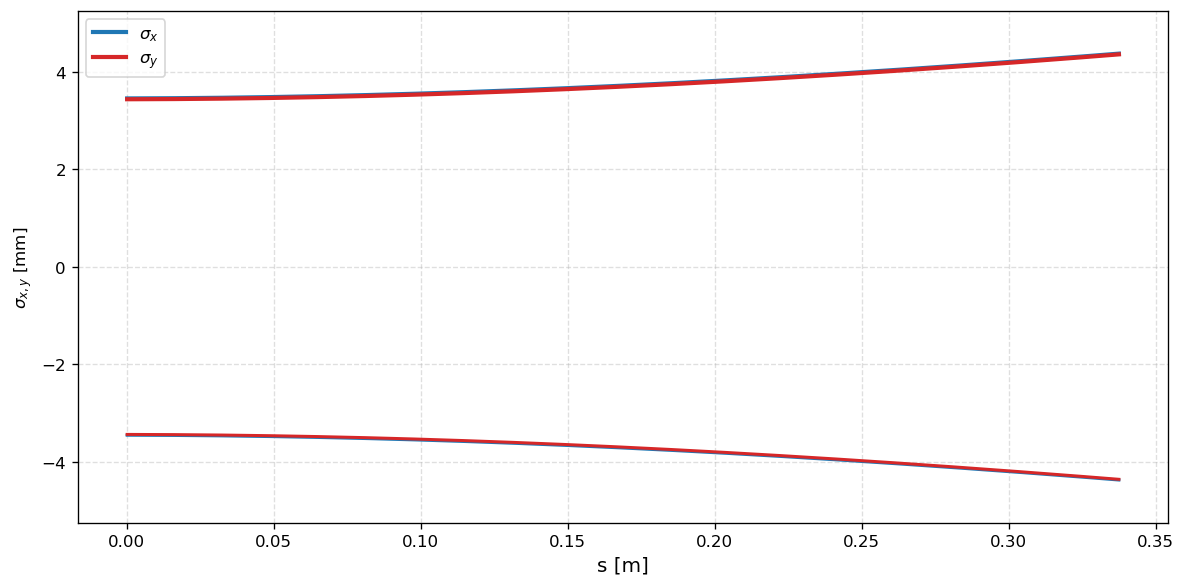

In [ ]:
lebt = create_lebt(B0T)
lebt.tt_dt_mm = 20


B1 = lebt.track(B0T)
I = B1.get_info()
    

print("\nX-X'")
print("emit =", I.emitt_x, "mm·mrad")
print("beta =", I.beta_x, "mm/mrad")
print("alpha =", I.alpha_x)

print("\nY-Y'")
print("emit =", I.emitt_y, "mm·mrad")
print("beta =", I.beta_y, "mm/mrad")
print("alpha =", I.alpha_y)

print("\n4D")
print("emit4D =", I.emitt_4d**2, "(mm·mrad)^2")


M1 = B1.get_phase_space("%X %xp %Y %yp")

x  = M1[:,0]
xp = M1[:,1]
y  = M1[:,2]
yp = M1[:,3]

#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y,yp,"y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")

T = lebt.get_transport_table("%t %sigma_X %sigma_Y %N %mean_P")

t_rf  = T[:, 0]
mx = T[:, 1]
my = T[:, 2]
N  = T[:, 3]
P = T[:, 4]

# Convert ct to s

m = 12 * 931.494  # MeV/c^2
beta = P / np.sqrt(P**2 + m**2)
s = beta * t_rf   # mm
s = s / 1000      # → m

# Plot rms 
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  mx,  color=color_x, linewidth=2.5, linestyle='-',  label=r'$\sigma_x$')
ax.plot(s, -mx,  color=color_x, linewidth=1.8, linestyle='-')
ax.plot(s,  my,  color=color_y, linewidth=2.5, linestyle='-',  label=r'$\sigma_y$')
ax.plot(s, -my,  color=color_y, linewidth=1.8, linestyle='-')
ax.set_xlabel('s [m]', fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')

ax.set_xlim(0, 4.7)
ax.set_ylim(-max(mx)*1.2, max(mx)*1.2)

ax.legend(loc='upper left') 
ax.grid(True, linestyle='--', alpha=0.4)

#plot_lattice(ax)

plt.tight_layout()
plt.show()

#Plot transmission

#plt.figure(figsize=(10, 5), dpi=120)
#plt.plot(s, N/N[0]*100, color='tab:red', linewidth=2.5, linestyle='-', label='Transmission')
#plt.xlabel('s [m]', fontsize=12)
#plt.ylabel('Transmission [%]', fontsize=12)
#plt.xlim(0, 4.7) 
#plt.ylim(0, 105)
#plt.grid(True, linestyle='--', alpha=0.4)
